<a href="https://colab.research.google.com/github/nomanabdullah04/Natural-Language-Processing-NLP-/blob/main/Text_Processing_Bag_of_Intuition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Bag of words***

## 1. Core Architecture & Mathematical Foundations

The **Bag-of-Words (BoW)** model is a baseline vectorization technique in Natural Language Processing (NLP). It converts unstructured text documents into fixed-length numeric vectors by tracking word frequencies while completely discarding grammar rules, syntax layout, and sequential word order.

### A. The Two-Stage Preprocessing Pipeline
Before vector mapping occurs, raw sentences pass through strict normalization filters to eliminate vocabulary clutter:
1. **Lowercase Transformation:** Converts all input characters to lowercase (`He` → `he`, `She` → `she`, `Boy` → `boy`).
2. **Stopwords Filtering:** Instantly discards structural, low-information "glue words" circled in red (`he`, `she`, `is`, `a`, `and`, `are`).

### B. Vocabulary Mapping
After filtering out stopwords, the algorithm scans the entire text corpus to compile a distinct **Vocabulary (V)** containing only unique words:

\[V = \{\text{"boy"}, \text{"girl"}, \text{"good"}\}\]
\[\text{Total Vocabulary Size } (\lvert V \rvert) = 3\]


## 2. Step-by-Step Data Transformation

The text sentences on the lecture board transform mechanically through the pipeline:

### 🔹 Stage 1: Text to Normalized Token Sequences (\(S_i\))
* **Original Document 1:** `"He is a good boy"` \(\longrightarrow\) **S₁:** `["good", "boy"]`
* **Original Document 2:** `"She is a good girl"` \(\longrightarrow\) **S₂:** `["good", "girl"]`
* **Original Document 3:** `"Boy and girl are good"` \(\longrightarrow\) **S₃:** `["boy", "girl", "good"]`

###  Stage 2: Target Vector Generation
Each document is mapped to a numeric vector of length \(\lvert V \rvert = 3\), counting the occurrences of each unique word based on the alphabetical index slot:
* Index 0: `boy`
* Index 1: `girl`
* Index 2: `good`

---

## 3. Production Pipeline Vector Matrix

Here is the complete, explicit structural document frequency matrix corresponding to the lecture example:

```text
Vocabulary Mapping Reference:
[ 'boy' (Index 0), 'girl' (Index 1), 'good' (Index 2) ]

Document Vector Arrays:
Vector S1: [1, 0, 1]  # Maps to: 1 "boy",  0 "girl", 1 "good"
Vector S2: [0, 1, 1]  # Maps to: 0 "boy",  1 "girl", 1 "good"
Vector S3: [1, 1, 1]  # Maps to: 1 "boy",  1 "girl", 1 "good"

Unified Corpus Frequency Matrix:
[,  # S1 vector representation,  # S2 vector representation
    [1, 1, 1]   # S3 vector representation
]
```

---

## 4. Summary of Strategic Trade-offs

###  Advantages (Pros)
* **High Operational Simplicity:** Extremely straightforward to compute, scale, and feed directly into linear classification algorithms.
* **Effective Document Profiling:** Natively groups similar topical documents together based entirely on keyword presence.
* **Compressed Data Matrix:** Far less sparse than nesting a full one-hot encoded array for every single sentence character token.

###  Disadvantages (Cons)
* **Total Word Order Blindness:** Because it drops sequential context, the phrases *"not good, bad"* and *"bad, not good"* generate identical vectors, risking sentiment confusion.
* **Frequency Bias Distortion:** High-frequency words skew distance metrics heavily unless scaled by an inverse document frequency (TF-IDF) layer.
* **Semantic Blind Spot:** Captures zero relationship between synonyms; it maps `boy` and `girl` as completely independent coordinates.

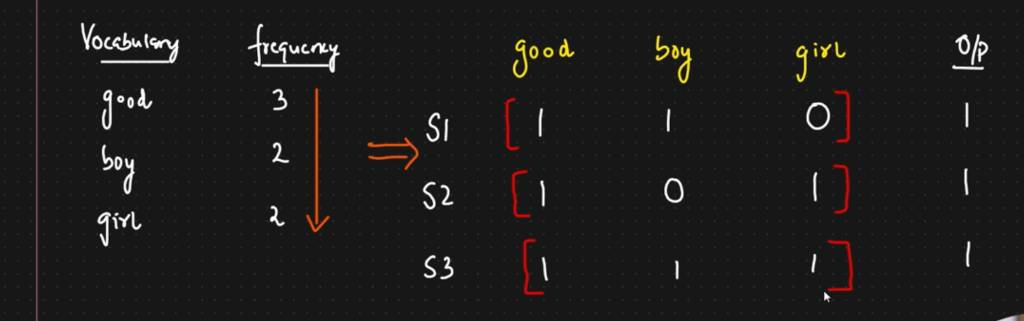

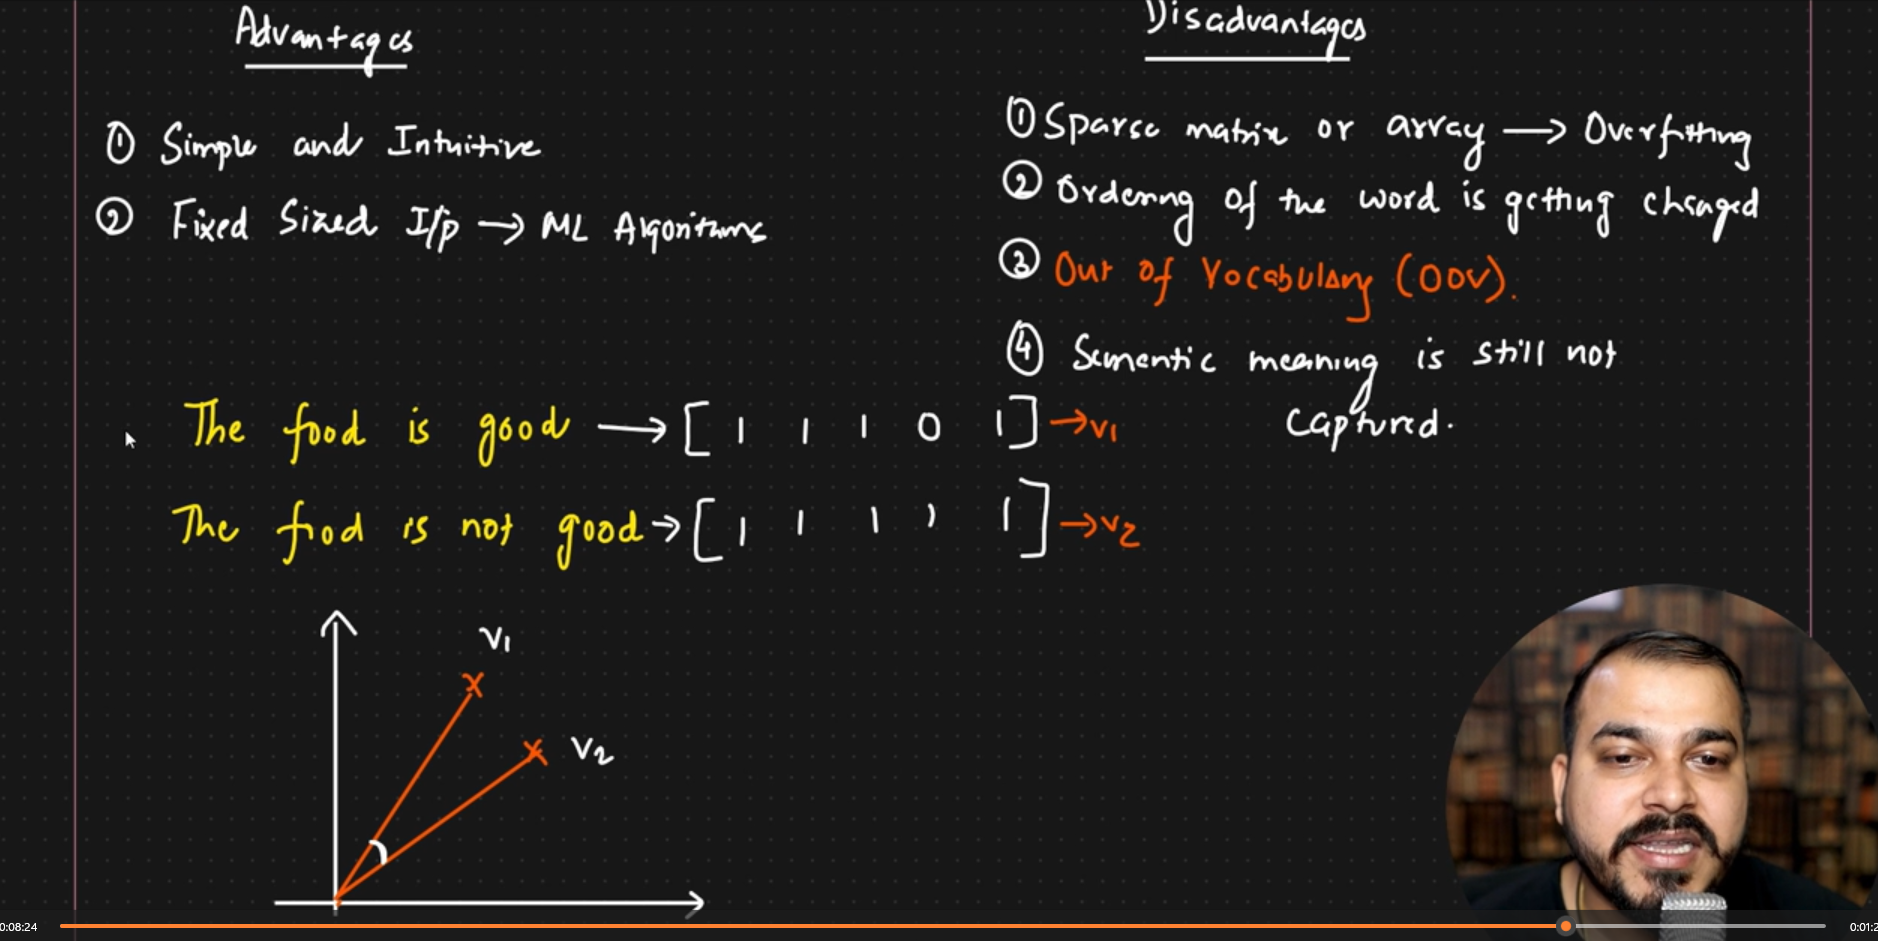


# ***Bag-of-Words (BoW) vs. Binary BoW***


## 1. Core Architecture & Mathematical Differences

While both models use an identical **Vocabulary (V)** derived from a preprocessed text corpus, they compute the numerical values inside the document matrix using completely different scoring functions.

### A. Standard Bag-of-Words (Term Frequency BoW)
The standard BoW model records the raw **Term Frequency (tf)**—the exact number of times a specific word token t appears inside a document d. The value at each index coordinate is an integer scalar:

\[X_{d, t} = f(t, d)\]

\[\text{Example: If } d = \text{"bad bad movie"}, \, \vec{v}(\text{"bad"}) = 2\]

### B. Binary Bag-of-Words (Presence/Absence BoW)
The Binary BoW model discards raw counts entirely. It acts as a boolean indicator, tracking only whether a word is **present or absent** in the document. The value at each index coordinate is strictly clipped to a binary scale:

\[X_{d, t} = \begin{cases} 1 & \text{if } f(t, d) > 0 \\ 0 & \text{if } f(t, d) = 0 \end{cases}\]

\[\text{Example: If } d = \text{"bad bad movie"}, \, \vec{v}(\text{"bad"}) = 1\]


## 2. Core Concept & Comparison Matrix

The difference between these models depends entirely on whether your machine learning classification task cares about the **repetition intensity** of a word or just its **raw occurrence**.

### Visual Comparison Example
Imagine a document contains the sentence: *"The food was bad, bad, bad."* After stripping stopwords, the token array reads: `["bad", "bad", "bad"]`.

| Vector Model | "bad" Column Value | Algorithmic Intuition |
| :--- | :--- | :--- |
| **Standard BoW** | `3` | *"The word appears 3 times. The intensity of this descriptor is exceptionally high."* |
| **Binary BoW** | `1` | *"The word 'bad' is present in this text. The number of times it repeats is irrelevant."* |


## 3. Production Pipeline Vector Matrix Comparison

Let us map a dynamic text corpus containing highly repetitive strings to see exactly how the final numerical arrays change between the two models.

### Baseline Preprocessed Corpus
* **Document 1 (D₁):** `"excellent performance excellent style"` \(\longrightarrow\) `["excellent", "performance", "style"]`
* **Document 2 (D₂):** `"poor design poor execution"` \(\longrightarrow\) `["poor", "design", "execution"]`

### Master Vocabulary Mappings
\[V = \{\text{"design" (0)}, \text{"excellent" (1)}, \text{"execution" (2)}, \text{"performance" (3)}, \text{"poor" (4)}, \text{"style" (5)}\}\]

### The Numerical Matrices

```text
1. Standard Bag-of-Words Matrix (Term Frequency):
D1 Vector: [0, 2, 0, 1, 0, 1]  # 'excellent' has an integer count of 2
D2 Vector: [1, 0, 1, 0, 2, 0]  # 'poor' has an integer count of 2

Unified Standard Matrix:
[,
  [1, 0, 1, 0, 2, 0]
]

2. Binary Bag-of-Words Matrix (Presence/Absence):
D1 Vector: [0, 1, 0, 1, 0, 1]  # Clipped down to binary 1
D2 Vector: [1, 0, 1, 0, 1, 0]  # Clipped down to binary 1

Unified Binary Matrix:
[,
  [1, 0, 1, 0, 1, 0]
]
```



## 4. Summary of Strategic Trade-offs

###  Standard BoW Pros & Cons
* **Pros:** Preserves the internal emphasis and intensity of words; ideal for long-form topic classification where keyword density signals relevance.
* **Cons:** Highly vulnerable to document length bias; a single long, repetitive document can heavily distort geometric distance metrics, dominating the model space.

###  Binary BoW Pros & Cons
* **Pros:** Minimizes long-document bias natively; performs exceptionally well on short text blocks (e.g., tweets, SMS text alerts, product reviews) and works efficiently with Bernoulli Naive Bayes classifiers.
* **Cons:** Completely blind to word frequency scaling; it treats a review containing one mention of a keyword exactly the same as a review that repeats it multiple times.
